In [2]:
import pandas as pd
import numpy as np

df = pd.read_excel(
    "../data/raw/sales.xlsx"
)

df["Date"] = pd.to_datetime(df["Date"])

df["State"] = df["State"].str.strip()

df.drop(columns=["Category"], inplace=True)

df = df.sort_values(["State", "Date"])

In [3]:
df["lag_1"] = (
    df.groupby("State")["Total"]
    .shift(1)
)

df["lag_4"] = (
    df.groupby("State")["Total"]
    .shift(4)
)

df["lag_12"] = (
    df.groupby("State")["Total"]
    .shift(12)
)

In [6]:
print(df.head(20))

        State       Date      Total        lag_1        lag_4       lag_12
86    Alabama 2019-10-06  129106730          NaN          NaN          NaN
3397  Alabama 2019-10-13  123782286  129106730.0          NaN          NaN
5246  Alabama 2019-10-20  116218909  123782286.0          NaN          NaN
7095  Alabama 2019-10-27  109968011  116218909.0          NaN          NaN
43    Alabama 2019-11-03  112189104  109968011.0  129106730.0          NaN
172   Alabama 2019-11-10  110932913  112189104.0  123782286.0          NaN
4472  Alabama 2019-11-17  109056410  110932913.0  116218909.0          NaN
6321  Alabama 2019-11-24  113040422  109056410.0  109968011.0          NaN
0     Alabama 2019-12-01  109574036  113040422.0  112189104.0          NaN
129   Alabama 2019-12-08  108083724  109574036.0  110932913.0          NaN
3956  Alabama 2019-12-15  108528456  108083724.0  109056410.0          NaN
5805  Alabama 2019-12-22  116541575  108528456.0  113040422.0          NaN
7654  Alabama 2019-12-29 

In [5]:
print(df[[
    "State",
    "Date",
    "Total",
    "lag_1",
    "lag_4"
]].head(15))

        State       Date      Total        lag_1        lag_4
86    Alabama 2019-10-06  129106730          NaN          NaN
3397  Alabama 2019-10-13  123782286  129106730.0          NaN
5246  Alabama 2019-10-20  116218909  123782286.0          NaN
7095  Alabama 2019-10-27  109968011  116218909.0          NaN
43    Alabama 2019-11-03  112189104  109968011.0  129106730.0
172   Alabama 2019-11-10  110932913  112189104.0  123782286.0
4472  Alabama 2019-11-17  109056410  110932913.0  116218909.0
6321  Alabama 2019-11-24  113040422  109056410.0  109968011.0
0     Alabama 2019-12-01  109574036  113040422.0  112189104.0
129   Alabama 2019-12-08  108083724  109574036.0  110932913.0
3956  Alabama 2019-12-15  108528456  108083724.0  109056410.0
5805  Alabama 2019-12-22  116541575  108528456.0  113040422.0
7654  Alabama 2019-12-29  106949922  116541575.0  109574036.0
473   Alabama 2020-01-05  104239954  106949922.0  108083724.0
989   Alabama 2020-01-12  108717628  104239954.0  108528456.0


In [7]:
df["rolling_mean_4"] = (
    df.groupby("State")["Total"]
    .transform(
        lambda x: x.rolling(4).mean()
    )
)

In [8]:
df["rolling_std_4"] = (
    df.groupby("State")["Total"]
    .transform(
        lambda x: x.rolling(4).std()
    )
)

In [ ]:
#month feature
df["month"] = df["Date"].dt.month

In [11]:
#quarter
df["quarter"] = df["Date"].dt.quarter

In [12]:
#weak of year
df["week_of_year"] = (
    df["Date"]
    .dt.isocalendar()
    .week
)

In [13]:
#year
df["year"] = df["Date"].dt.year

In [14]:
df["trend"] = np.arange(len(df))

In [15]:
print(df.head(15))

        State       Date      Total        lag_1        lag_4       lag_12  \
86    Alabama 2019-10-06  129106730          NaN          NaN          NaN   
3397  Alabama 2019-10-13  123782286  129106730.0          NaN          NaN   
5246  Alabama 2019-10-20  116218909  123782286.0          NaN          NaN   
7095  Alabama 2019-10-27  109968011  116218909.0          NaN          NaN   
43    Alabama 2019-11-03  112189104  109968011.0  129106730.0          NaN   
172   Alabama 2019-11-10  110932913  112189104.0  123782286.0          NaN   
4472  Alabama 2019-11-17  109056410  110932913.0  116218909.0          NaN   
6321  Alabama 2019-11-24  113040422  109056410.0  109968011.0          NaN   
0     Alabama 2019-12-01  109574036  113040422.0  112189104.0          NaN   
129   Alabama 2019-12-08  108083724  109574036.0  110932913.0          NaN   
3956  Alabama 2019-12-15  108528456  108083724.0  109056410.0          NaN   
5805  Alabama 2019-12-22  116541575  108528456.0  113040422.0   

In [16]:
##for xgboost we need to do encoding

from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df["state_encoded"] = (
    encoder.fit_transform(df["State"])
)

In [18]:
print(df.head(10))

        State       Date      Total        lag_1        lag_4  lag_12  \
86    Alabama 2019-10-06  129106730          NaN          NaN     NaN   
3397  Alabama 2019-10-13  123782286  129106730.0          NaN     NaN   
5246  Alabama 2019-10-20  116218909  123782286.0          NaN     NaN   
7095  Alabama 2019-10-27  109968011  116218909.0          NaN     NaN   
43    Alabama 2019-11-03  112189104  109968011.0  129106730.0     NaN   
172   Alabama 2019-11-10  110932913  112189104.0  123782286.0     NaN   
4472  Alabama 2019-11-17  109056410  110932913.0  116218909.0     NaN   
6321  Alabama 2019-11-24  113040422  109056410.0  109968011.0     NaN   
0     Alabama 2019-12-01  109574036  113040422.0  112189104.0     NaN   
129   Alabama 2019-12-08  108083724  109574036.0  110932913.0     NaN   

      rolling_mean_4  rolling_std_4  month  quarter  week_of_year  year  \
86               NaN            NaN     10        4            40  2019   
3397             NaN            NaN     10    

In [19]:
print(df.isnull().sum())

State               0
Date                0
Total               0
lag_1              43
lag_4             172
lag_12            516
rolling_mean_4    129
rolling_std_4     129
month               0
quarter             0
week_of_year        0
year                0
trend               0
state_encoded       0
dtype: int64


In [20]:
df = df.dropna()

In [21]:
print(df.head())

print(df.columns)

print(df.shape)

        State       Date      Total        lag_1        lag_4       lag_12  \
7654  Alabama 2019-12-29  106949922  116541575.0  109574036.0  129106730.0   
473   Alabama 2020-01-05  104239954  106949922.0  108083724.0  123782286.0   
989   Alabama 2020-01-12  108717628  104239954.0  108528456.0  116218909.0   
4730  Alabama 2020-01-19  105904866  108717628.0  116541575.0  109968011.0   
6579  Alabama 2020-01-26  106265737  105904866.0  106949922.0  112189104.0   

      rolling_mean_4  rolling_std_4  month  quarter  week_of_year  year  \
7654    1.100259e+08   4.394316e+06     12        4            52  2019   
473     1.090650e+08   5.289665e+06      1        1             1  2020   
989     1.091123e+08   5.284112e+06      1        1             2  2020   
4730    1.064531e+08   1.877365e+06      1        1             3  2020   
6579    1.062820e+08   1.847948e+06      1        1             4  2020   

      trend  state_encoded  
7654     12              0  
473      13           

In [26]:
features = [
    "lag_1",
    "lag_4",
    "lag_12",
    "rolling_mean_4",
    "rolling_std_4",
    "month",
    "quarter",
    "week_of_year",
    "year",
    "trend",
    "state_encoded"
]

In [28]:
target = "Total"

In [23]:

#splitting of data
split_index = int(len(df) * 0.8)

train_df = df.iloc[:split_index]

valid_df = df.iloc[split_index:]

In [29]:
X_train = train_df[features]

y_train = train_df[target]

In [30]:
X_valid = valid_df[features]

y_valid = valid_df[target]

In [31]:
print(train_df["Date"].min())
print(train_df["Date"].max())

print(valid_df["Date"].min())
print(valid_df["Date"].max())

2019-12-29 00:00:00
2023-05-07 00:00:00
2019-12-29 00:00:00
2023-05-07 00:00:00


In [32]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

In [33]:
#save trained and validation data

train_df.to_csv(
    "../data/processed/train_data.csv",
    index=False
)

valid_df.to_csv(
    "../data/processed/valid_data.csv",
    index=False
)

In [ ]:
##model training
##XGBOOST

In [37]:
!pip install xgboost

In [38]:
from xgboost import XGBRegressor

In [39]:
model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

In [40]:
model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [41]:
y_pred = model.predict(X_valid)

In [42]:
print(y_pred[:10])

[1.6444054e+08 1.6515285e+08 1.6717862e+08 1.7210714e+08 1.7284819e+08
 1.7486570e+08 1.7447766e+08 1.8018435e+08 1.8055678e+08 1.8218720e+08]


In [43]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

In [44]:
mae = mean_absolute_error(y_valid, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_valid, y_pred)
)

mape = mean_absolute_percentage_error(
    y_valid,
    y_pred
)

In [45]:
print("MAE:", mae)

print("RMSE:", rmse)

print("MAPE:", mape)

MAE: 5081481.5
RMSE: 12606199.783438623
MAPE: 0.045734066516160965


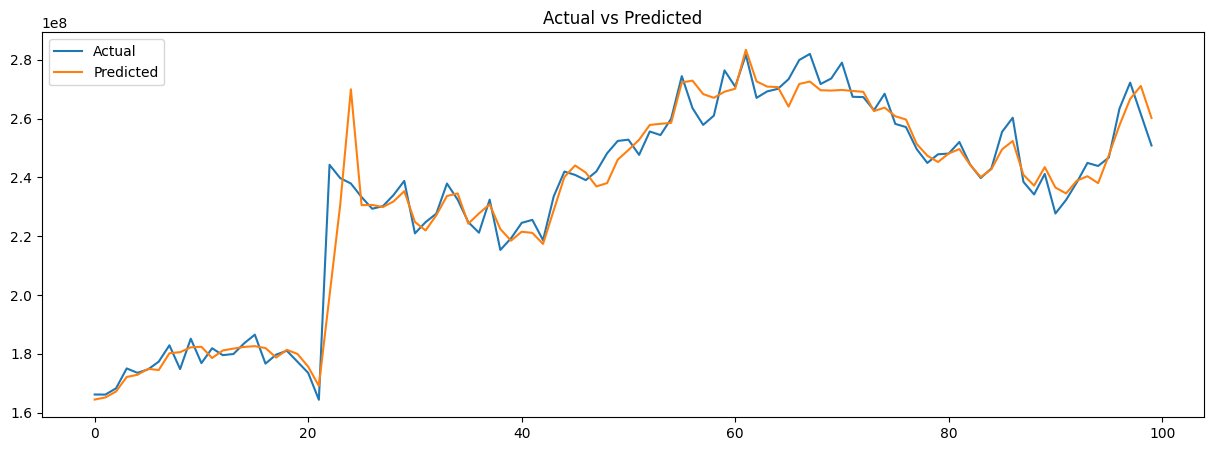

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

plt.plot(
    y_valid.values[:100],
    label="Actual"
)

plt.plot(
    y_pred[:100],
    label="Predicted"
)

plt.legend()

plt.title("Actual vs Predicted")

plt.show()

In [49]:
importance = model.feature_importances_

feature_importance = pd.DataFrame({
    "feature": features,
    "importance": importance
})

feature_importance = (
    feature_importance
    .sort_values("importance", ascending=False)
)

print(feature_importance)

           feature  importance
3   rolling_mean_4    0.936701
0            lag_1    0.055540
1            lag_4    0.002436
9            trend    0.001412
2           lag_12    0.001293
10   state_encoded    0.000736
4    rolling_std_4    0.000633
7     week_of_year    0.000483
5            month    0.000430
8             year    0.000336
6          quarter    0.000000


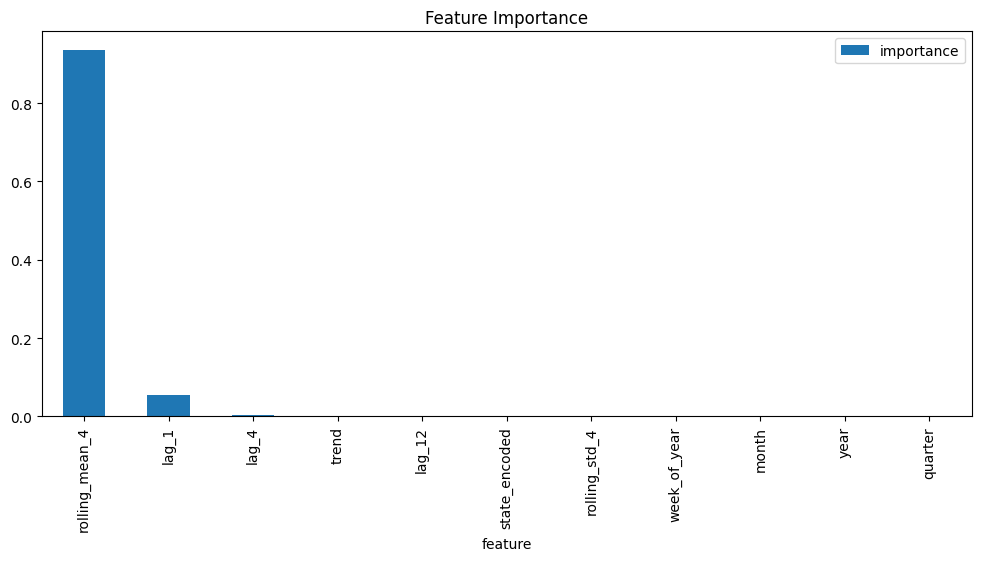

In [50]:
feature_importance.plot(
    x="feature",
    y="importance",
    kind="bar",
    figsize=(12,5)
)

plt.title("Feature Importance")

plt.show()

train prediction


In [51]:
train_pred = model.predict(X_train)

In [52]:
train_mape = mean_absolute_percentage_error(
    y_train,
    train_pred
)

In [53]:
print("Train MAPE:", train_mape * 100)

print("Validation MAPE:", mape * 100)

Train MAPE: 1.485979463905096
Validation MAPE: 4.5734066516160965


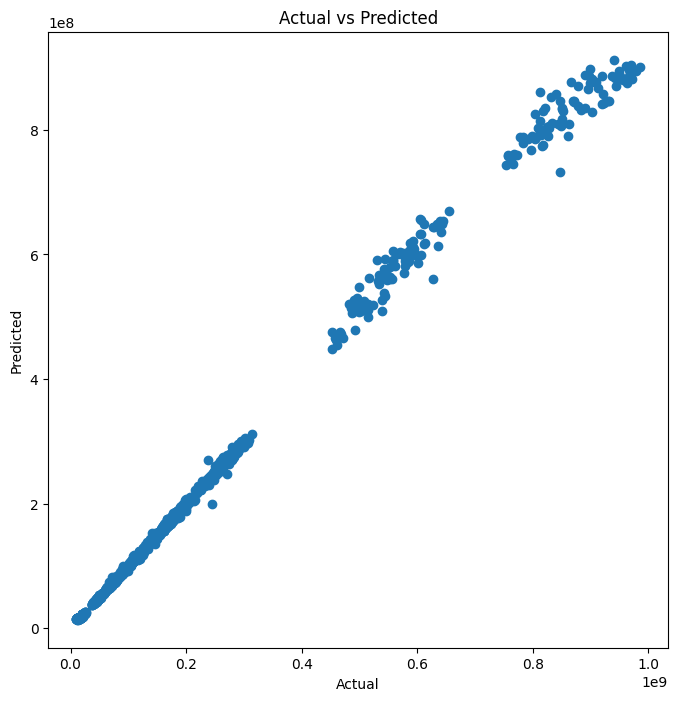

In [54]:
plt.figure(figsize=(8,8))

plt.scatter(y_valid, y_pred)

plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.title("Actual vs Predicted")

plt.show()

In [55]:
results = valid_df.copy()

results["actual"] = y_valid.values

results["predicted"] = y_pred

results["error_percent"] = (
    np.abs(
        (results["actual"] - results["predicted"])
        / results["actual"]
    ) * 100
)

In [56]:
worst_cases = (
    results
    .sort_values("error_percent", ascending=False)
    .head(10)
)

print(worst_cases[[
    "State",
    "Date",
    "actual",
    "predicted",
    "error_percent"
]])

        State       Date    actual   predicted  error_percent
252   Vermont 2020-03-01  10321603  16322476.0      58.138963
3520  Vermont 2020-12-13  10595475  15778109.0      48.913654
768   Vermont 2020-03-08  11002690  16264166.0      47.819906
854   Vermont 2020-02-09  10245583  15125750.0      47.631911
5369  Vermont 2020-12-20  10830190  15863221.0      46.472232
6616  Vermont 2020-01-26  10013202  14603607.0      45.843527
3950  Vermont 2020-11-15  10771670  15639845.0      45.194246
338   Vermont 2020-02-02  10422771  15125750.0      45.122156
4896  Vermont 2020-04-19  10470686  15137878.0      44.573889
6745  Vermont 2020-04-26  10511675  15093603.0      43.588943


In [57]:
import joblib

joblib.dump(
    model,
    "../saved_models/xgboost_model.pkl"
)

['../saved_models/xgboost_model.pkl']

In [59]:
# Load the model back from the file
loaded_model = joblib.load("../saved_models/xgboost_model.pkl")

# Now you can use it to predict
loaded_pred = loaded_model.predict(X_valid)
